# 1.1 MACCS mechanism-aligned transfer benchmark

This notebook establishes the canonical MACCS benchmark for the controlled
Ru-AHK → Ru-AHO transfer problem.

The target domain is fixed as inner-sphere Ru-AHO. Three predictive settings
are evaluated under the same five target folds and the same 11 classical
regressors:

1. target-only Ru-AHO;
2. mechanism-aligned transfer from inner-sphere Ru-AHK;
3. mechanism-mismatched transfer from outer-sphere Ru-AHK.

For each transfer source, mixed transfer and delta learning are both evaluated.
Pooled out-of-fold R² is the primary metric; MAE and RMSE are reported as
supporting metrics.

Outputs are written to:

`results/1_1_maccs_mechanism_transfer/`

Plot palette: light gray target-only, teal aligned transfer, terracotta mismatched transfer.
The full error KDE is accompanied by a three-layer high-error histogram.
Its x-axis shows absolute error (default 0.5 < error <= 2.5 kcal/mol),
its depth separates the selected models, and its vertical axis shows probability density.
Shared bins have density = count / (ALL model predictions * bin width).
Tail values are never renormalized; out-of-window counts are saved in the summary CSV.
Bar gaps are cosmetic: density uses the full statistical bin width.
SHOW_TEXT and SHOW_LEGEND default to False; figures export to SVG only.
Training and model selection are unchanged.

SI heatmaps retain titles, algorithm names, strategy labels and colorbar labels by default (`SI_HEATMAP_SHOW_TEXT = True`), independently of the main-text figure switches.


In [1]:
import warnings
from collections import OrderedDict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pandas.errors import EmptyDataError

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        # Use the original font and export SVG glyphs as paths for consistent PPT rendering.
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "legend.fontsize": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "svg.fonttype": "path",
    }
)

SOURCE_RULE_COLORS = {
    "target_only": "#B0B0B0",
    "mechanism_aligned": "#278579",
    "mechanism_mismatched": "#B56F61",
    "all_ru_ahk": "#7B61A8",
    "substrate_similar": "#009E73",
    "ligand_similar": "#E69F00",
    "reaction_feature_similar": "#56B4E9",
}

from rdkit import Chem, RDLogger
from rdkit.Chem import rdMolDescriptors
from rdkit.DataStructs import ConvertToNumpyArray

try:
    from rdkit.Chem import rdFingerprintGenerator
    HAS_FINGERPRINT_GENERATOR = True
except Exception:
    rdFingerprintGenerator = None
    HAS_FINGERPRINT_GENERATOR = False

try:
    from rdkit.Avalon import pyAvalonTools
    HAS_AVALON = True
except Exception:
    pyAvalonTools = None
    HAS_AVALON = False

from sklearn.ensemble import (
    AdaBoostRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR, LinearSVR
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
warnings.filterwarnings("ignore", category=ConvergenceWarning)
RDLogger.DisableLog("rdApp.warning")

RANDOM_STATE = 42
N_FOLDS = 5
MACCS_LENGTH = 167
TARGET_COLUMN = "ddG"
COMPONENT_COLUMNS = [
    "Reactant SMILES",
    "Product SMILES",
    "Additive SMILES",
    "Solvent SMILES",
    "Ligand SMILES",
]
CONDITION_COLUMNS = ["Pressure/atm", "Temperature/C", "S/C"]


# Keep result-level and feature-level caches separate.
# Recompute model predictions only when intentionally requested.
FORCE_RECOMPUTE_RESULTS = False
FORCE_RECOMPUTE_FEATURES = False

# Presentation switch for the selected parity plots.
# False: show the full diagnostic annotations.

# Presentation switch for the ridgeline absolute-error density plot.
# True: hide title, x-axis label, and MAE text for figure assembly.
# False: show the full diagnostic annotations.

# Shared KDE bandwidth (kcal/mol) for all three error distributions.
# The same bandwidth and x-grid are used for Target-only,
# Different-mechanism transfer, and Same-mechanism transfer.
RIDGELINE_KDE_BANDWIDTH = 0.12

# Vertical spacing and fill transparency for the three ridgelines.
RIDGELINE_VERTICAL_GAP = 1.15
RIDGELINE_FILL_ALPHA = 0.28

# Visual settings for the overlaid KDE comparison.
# This view uses the same KDE x-grid and bandwidth as the ridgeline plot.
OVERLAY_DENSITY_FILL_ALPHA = 0.14
OVERLAY_DENSITY_LINEWIDTH = 2.0

# Error-threshold summary used as a compact inset / standalone panel.
# Each bar reports the fraction of ALL OOF reactions whose absolute error
# exceeds the corresponding threshold.
ERROR_THRESHOLDS = [0.50, 1.00, 1.50]

# [left, bottom, width, height] of the threshold inset in axes coordinates.
THRESHOLD_INSET_BOUNDS = [0.56, 0.42, 0.39, 0.43]

# High-error distribution inset matching Figure 2C.
PARITY_BASELINE_COLOR = "#858585"  # Darker scatter markers only.
PARITY_BASELINE_ALPHA = 0.85
EXPORT_ERROR_DENSITY = True
ERROR_TAIL_MIN = 0.5
ERROR_TAIL_MAX = 2.5
ERROR_TAIL_N_BINS = 10
ERROR_3D_FIGSIZE = (6.6, 5.5)
ERROR_3D_ELEV = 25
ERROR_3D_AZIM = -60
ERROR_3D_LAYER_GAP = 1.05
ERROR_3D_BAR_DEPTH = 0.38
ERROR_3D_COLOR_LIGHTEN = 0.22
ERROR_3D_SHADE_STRENGTH = 0.12
ERROR_3D_DENSITY_MAX = None


def find_project_root(start=None):
    """Find the project root containing the canonical data/transfer directory."""
    start = Path.cwd() if start is None else Path(start)
    start = start.resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / "data" / "transfer").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TRANSFER_DIR = PROJECT_ROOT / "data" / "transfer"
OUT_DIR = PROJECT_ROOT / "results" / "1_1_maccs_mechanism_transfer"
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR = OUT_DIR / "figures"
FEATURE_CACHE_DIR = OUT_DIR / "feature_cache"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
FEATURE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

OOF_PATH = TABLE_DIR / "maccs_ru_inner_outer_to_aho_inner_oof_predictions.csv"

FEATURE_CACHE_PATH = FEATURE_CACHE_DIR / "maccs_combined_feature_matrix.npy"

# Remove legacy sidecar outputs from earlier, more verbose versions of this notebook.
OBSOLETE_OUTPUT_PATHS = [
    TABLE_DIR / "maccs_model_parameter_audit.csv",
    TABLE_DIR / "maccs_ru_domain_summary.csv",
    TABLE_DIR / "maccs_ru_inner_outer_to_aho_inner_errors.csv",
]
for obsolete_path in OBSOLETE_OUTPUT_PATHS:
    if obsolete_path.exists():
        obsolete_path.unlink()
for obsolete_path in FEATURE_CACHE_DIR.glob("*maccs*.metadata.json"):
    obsolete_path.unlink()
for obsolete_path in FEATURE_CACHE_DIR.glob("*maccs*.npy"):
    if obsolete_path != FEATURE_CACHE_PATH:
        obsolete_path.unlink()

DOMAIN_FILES = OrderedDict(
    [
        ("ru_ahk_inner", TRANSFER_DIR / "ru_ahk_inner.csv"),
        ("ru_ahk_outer", TRANSFER_DIR / "ru_ahk_outer.csv"),
        ("ru_aho_inner", TRANSFER_DIR / "ru_aho_inner.csv"),
    ]
)

TRANSFER_TASKS = [
    {
        "task_id": "ru_ahk_inner_to_ru_aho_inner",
        "source_key": "ru_ahk_inner",
        "target_key": "ru_aho_inner",
        "source_domain": "inner",
        "target_domain": "inner",
        "relation_label": "Same mechanism",
        "scene_label": "Ru-AHK inner -> Ru-AHO inner",
    },
    {
        "task_id": "ru_ahk_outer_to_ru_aho_inner",
        "source_key": "ru_ahk_outer",
        "target_key": "ru_aho_inner",
        "source_domain": "outer",
        "target_domain": "inner",
        "relation_label": "Different mechanism",
        "scene_label": "Ru-AHK outer -> Ru-AHO inner",
    },
]

OOF_COLUMNS = [
    "model",
    "task_id",
    "scene_label",
    "source_domain",
    "target_domain",
    "relation_label",
    "method_label",
    "fold_id",
    "target_index",
    "y_true",
    "y_pred",
]
ERROR_COLUMNS = ["model", "task_id", "method_label", "error"]


def read_csv_or_empty(path, columns=None):
    """Read a CSV cache safely, returning an empty table when the file has no parseable content."""
    if columns is None:
        columns = []
    path = Path(path)
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame(columns=columns)
    try:
        return pd.read_csv(path)
    except EmptyDataError:
        return pd.DataFrame(columns=columns)


def csv_has_data_rows(path, required_columns=None):
    """Return True only when a cached CSV has at least one row and the expected columns."""
    if required_columns is None:
        required_columns = []
    cache = read_csv_or_empty(path, columns=required_columns)
    if len(cache) == 0:
        return False
    missing = [col for col in required_columns if col not in cache.columns]
    return len(missing) == 0


RESULT_CACHE_AVAILABLE = csv_has_data_rows(OOF_PATH, required_columns=OOF_COLUMNS)
NEED_FEATURE_MATRICES = FORCE_RECOMPUTE_RESULTS or not RESULT_CACHE_AVAILABLE

print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUT_DIR}")
print(f"Result cache available: {RESULT_CACHE_AVAILABLE}")
print(f"Feature matrices required in this run: {NEED_FEATURE_MATRICES}")

# =========================
# Figure display mode
# =========================
# Positive display switches for the publication plots. True = show.
# Axis lines, tick marks and tick numbers are retained in either mode.
SHOW_TEXT = False    # Main-text figures: titles, axis labels and annotations
SI_HEATMAP_SHOW_TEXT = True  # SI heatmap labels are independent of SHOW_TEXT
SHOW_LEGEND = False  # Legends, controlled independently of SHOW_TEXT


Project root: /home/syz/ru-mechanism-transfer
Output directory: /home/syz/ru-mechanism-transfer/results/1_1_maccs_mechanism_transfer
Result cache available: True
Feature matrices required in this run: False


## 1. Load the three canonical Ru domains

The notebook reads only the three curated transfer-domain files. No task table is inferred from filenames and no cross-metal filtering is performed.


In [2]:
def _standardize_domain_table(df, dataset_label):
    """Return a clean table with the columns required for MACCS modeling."""
    df = df.copy()
    missing = [col for col in [TARGET_COLUMN, "Reactant SMILES", "Product SMILES"] if col not in df.columns]
    if missing:
        raise ValueError(f"{dataset_label} is missing required columns: {missing}")

    for col in COMPONENT_COLUMNS:
        if col not in df.columns:
            df[col] = ""
        df[col] = df[col].fillna("").astype(str).str.strip()

    for col in CONDITION_COLUMNS:
        if col not in df.columns:
            df[col] = 0.0
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

    df[TARGET_COLUMN] = pd.to_numeric(df[TARGET_COLUMN], errors="coerce")
    df = df.dropna(subset=[TARGET_COLUMN, "Reactant SMILES", "Product SMILES"]).reset_index(drop=True)
    if len(df) < 2:
        raise ValueError(f"{dataset_label} has too few valid rows after cleaning.")
    return df


def load_domain(path, dataset_label):
    if not path.exists():
        raise FileNotFoundError(f"Cannot find {dataset_label}: {path}")
    return _standardize_domain_table(pd.read_csv(path), dataset_label)


DOMAINS = OrderedDict((key, load_domain(path, key)) for key, path in DOMAIN_FILES.items())

DOMAIN_SUMMARY = pd.DataFrame(
    [
        {
            "domain_key": key,
            "path": str(DOMAIN_FILES[key].relative_to(PROJECT_ROOT)),
            "n_samples": len(df),
            "n_reactants": df["Reactant SMILES"].nunique(),
            "n_ligands": df["Ligand SMILES"].nunique() if "Ligand SMILES" in df.columns else np.nan,
            "ddG_mean": df[TARGET_COLUMN].mean(),
            "ddG_std": df[TARGET_COLUMN].std(),
        }
        for key, df in DOMAINS.items()
    ]
)
display(DOMAIN_SUMMARY)


,domain_key,path,n_samples,n_reactants,n_ligands,ddG_mean,ddG_std
0,ru_ahk_inner,data/transfer/ru_ahk_inner.csv,495,214,41,2.077446,0.959506
1,ru_ahk_outer,data/transfer/ru_ahk_outer.csv,1539,345,304,1.971399,0.865312
2,ru_aho_inner,data/transfer/ru_aho_inner.csv,98,38,22,1.910037,0.950583


## 2. Build or load cached MACCS feature matrices

Each reaction is represented by concatenated MACCS key fingerprints for the reactant, product, additive, solvent, and ligand, followed by numeric reaction-condition features. No metal descriptor is appended because the benchmark is restricted to Ru domains.

The computed MACCS matrices are cached as one combined `.npy` file under `feature_cache/`. On later runs, the notebook reloads this matrix and slices it back into the three canonical Ru domains by the current input-table row counts. If the input data are changed while keeping exactly the same row counts, set `FORCE_RECOMPUTE_FEATURES = True` once to rebuild the cache.


In [3]:
def _bitvect_to_pm1(bitvect, nbits):
    arr = np.zeros((nbits,), dtype=np.int8)
    ConvertToNumpyArray(bitvect, arr)
    return np.where(arr > 0, 1, -1).astype(np.int8)


def _empty_pm1(nbits):
    return -np.ones((nbits,), dtype=np.int8)


def build_maccs_vector(smiles):
    """Return a single-molecule MACCS key vector encoded as {-1, +1}.

    RDKit MACCS keys have 167 positions. Position 0 is retained to keep the
    standard RDKit bit-vector length and avoid hidden dimensionality changes.
    """
    mol = Chem.MolFromSmiles(smiles) if isinstance(smiles, str) and smiles.strip() else None
    if mol is None:
        return _empty_pm1(MACCS_LENGTH)
    fp = rdMolDescriptors.GetMACCSKeysFingerprint(mol)
    return _bitvect_to_pm1(fp, MACCS_LENGTH)


def build_feature_matrix(df, cache=None):
    if cache is None:
        cache = {}
    rows = []
    for _, row in df.iterrows():
        component_vectors = []
        for col in COMPONENT_COLUMNS:
            smiles = str(row[col]) if pd.notna(row[col]) else ""
            if smiles not in cache:
                cache[smiles] = build_maccs_vector(smiles)
            component_vectors.append(cache[smiles])
        rows.append(np.concatenate(component_vectors))
    x_maccs = np.asarray(rows, dtype=np.float32)
    x_conditions = df[CONDITION_COLUMNS].astype(float).to_numpy(dtype=np.float32)
    return np.concatenate([x_maccs, x_conditions], axis=1).astype(np.float32)


def expected_feature_dim():
    return int(MACCS_LENGTH * len(COMPONENT_COLUMNS) + len(CONDITION_COLUMNS))


def domain_cache_slices():
    slices = OrderedDict()
    start = 0
    for key, df in DOMAINS.items():
        stop = start + len(df)
        slices[key] = slice(start, stop)
        start = stop
    return slices


def load_cached_feature_matrices():
    if FORCE_RECOMPUTE_FEATURES or not FEATURE_CACHE_PATH.exists():
        return None
    try:
        matrix = np.load(FEATURE_CACHE_PATH)
        expected_shape = (sum(len(df) for df in DOMAINS.values()), expected_feature_dim())
        if matrix.shape != expected_shape:
            print(f"Cached MACCS matrix has shape {matrix.shape}, expected {expected_shape}; rebuilding.")
            return None
        matrix = matrix.astype(np.float32, copy=False)
        slices = domain_cache_slices()
        features = OrderedDict((key, matrix[slices[key]]) for key in DOMAINS.keys())
        print(f"Loaded cached combined MACCS feature matrix: {matrix.shape}")
        return features
    except Exception as exc:
        print(f"Could not load cached MACCS feature matrix: {exc!r}; rebuilding.")
        return None


def save_cached_feature_matrices(features):
    matrix = np.vstack([features[key] for key in DOMAINS.keys()]).astype(np.float32, copy=False)
    np.save(FEATURE_CACHE_PATH, matrix)
    print(f"Saved combined MACCS feature cache: {FEATURE_CACHE_PATH} ({matrix.shape})")


FEATURE_CACHE = {}
FEATURES = OrderedDict()
TARGETS = OrderedDict((key, df[TARGET_COLUMN].to_numpy(dtype=float)) for key, df in DOMAINS.items())

if NEED_FEATURE_MATRICES:
    cached_features = load_cached_feature_matrices()
    if cached_features is not None:
        FEATURES = cached_features
    else:
        for key, df in DOMAINS.items():
            print(f"Building MACCS features for {key}: {len(df)} rows")
            FEATURES[key] = build_feature_matrix(df, cache=FEATURE_CACHE)
            print(f"  feature shape = {FEATURES[key].shape}")
        save_cached_feature_matrices(FEATURES)
else:
    print("OOF predictions are already cached. Feature matrices are not loaded in this run.")


OOF predictions are already cached. Feature matrices are not loaded in this run.


## 3. Selected classical model set

The model set is explicitly defined below. 

In [4]:
MACCS_MODEL_FACTORIES = OrderedDict(
    [
        # ("AdaBoostRegressor", lambda: AdaBoostRegressor(random_state=RANDOM_STATE)),
        ("ExtraTreesRegressor", lambda: ExtraTreesRegressor(n_jobs=-1, random_state=RANDOM_STATE)),
        ("GradientBoostingRegressor", lambda: GradientBoostingRegressor(random_state=RANDOM_STATE)),
        ("HistGradientBoostingRegressor", lambda: HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
        ("RandomForestRegressor", lambda: RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE)),
        (
            "GaussianProcessRegressor",
            lambda: make_pipeline(
                StandardScaler(),
                GaussianProcessRegressor(normalize_y=True, alpha=1e-6, random_state=RANDOM_STATE),
            ),
        ),
        ("KNeighborsRegressor", lambda: make_pipeline(StandardScaler(), KNeighborsRegressor())),
        ("SVR", lambda: make_pipeline(StandardScaler(), SVR())),
        (
            "LinearSVR",
            lambda: make_pipeline(
                StandardScaler(),
                LinearSVR(random_state=RANDOM_STATE, max_iter=5000),
            ),
        ),
        ("DecisionTreeRegressor", lambda: DecisionTreeRegressor(random_state=RANDOM_STATE)),
        ("ExtraTreeRegressor", lambda: ExtraTreeRegressor(random_state=RANDOM_STATE)),
    ]
)


MODEL_KEYS_TO_RUN = list(MACCS_MODEL_FACTORIES.keys())

MODEL_AUDIT_DF = pd.DataFrame(
    [
        {
            "model": model_key,
            "factory_repr": repr(MACCS_MODEL_FACTORIES[model_key]()),
        }
        for model_key in MODEL_KEYS_TO_RUN
    ]
)
display(MODEL_AUDIT_DF)


,model,factory_repr
0,ExtraTreesRegressor,"ExtraTreesRegressor(n_jobs=-1, random_state=42)"
1,GradientBoostingRegressor,GradientBoostingRegressor(random_state=42)
2,HistGradientBoostingRegressor,HistGradientBoostingRegressor(random_state=42)
3,RandomForestRegressor,"RandomForestRegressor(n_jobs=-1, random_state=42)"
4,GaussianProcessRegressor,"Pipeline(steps=[('standardscaler', StandardSca..."
5,KNeighborsRegressor,"Pipeline(steps=[('standardscaler', StandardSca..."
6,SVR,"Pipeline(steps=[('standardscaler', StandardSca..."
7,LinearSVR,"Pipeline(steps=[('standardscaler', StandardSca..."
8,DecisionTreeRegressor,DecisionTreeRegressor(random_state=42)
9,ExtraTreeRegressor,ExtraTreeRegressor(random_state=42)


## 4. Run pooled out-of-fold transfer benchmarks

The target domain is always Ru-AHO inner. Two source-to-target tasks are evaluated:

1. Ru-AHK inner -> Ru-AHO inner, representing same-mechanism transfer.
2. Ru-AHK outer -> Ru-AHO inner, representing different-mechanism transfer.

For classical MACCS models, the transfer strategies are direct source-target mixing and source-prior delta learning. The target-only baseline is computed once for the Ru-AHO target domain.

If a valid OOF prediction table already exists, it is loaded directly. Empty error logs are handled safely and do not trigger `EmptyDataError`.


In [5]:
def make_model(model_key):
    return MACCS_MODEL_FACTORIES[model_key]()


def predict_1d(model, x):
    pred = np.asarray(model.predict(x)).reshape(-1)
    return pred.astype(float)


def kfold_splitter(y_target):
    n_splits = min(int(N_FOLDS), int(len(y_target)))
    if n_splits < 2:
        raise ValueError("The Ru-AHO target domain has too few samples for OOF evaluation.")
    return KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)


def run_target_only_oof(model_key, x_target, y_target):
    rows = []
    cv = kfold_splitter(y_target)
    for fold_id, (train_idx, test_idx) in enumerate(cv.split(x_target, y_target), start=1):
        model = make_model(model_key)
        model.fit(x_target[train_idx], y_target[train_idx])
        pred = predict_1d(model, x_target[test_idx])
        for local_idx, truth, pred_value in zip(test_idx, y_target[test_idx], pred):
            rows.append(
                {
                    "model": model_key,
                    "task_id": "target_only_ru_aho_inner",
                    "scene_label": "Ru-AHO inner target-only",
                    "source_domain": "none",
                    "target_domain": "inner",
                    "relation_label": "Target-only",
                    "method_label": "Target-only",
                    "fold_id": int(fold_id),
                    "target_index": int(local_idx),
                    "y_true": float(truth),
                    "y_pred": float(pred_value),
                }
            )
    return rows


def run_transfer_oof(model_key, task, x_source, y_source, x_target, y_target):
    rows = []
    cv = kfold_splitter(y_target)

    source_prior_model = make_model(model_key)
    source_prior_model.fit(x_source, y_source)

    for fold_id, (train_idx, test_idx) in enumerate(cv.split(x_target, y_target), start=1):
        x_train = x_target[train_idx]
        y_train = y_target[train_idx]
        x_test = x_target[test_idx]
        y_test = y_target[test_idx]

        mixed_model = make_model(model_key)
        x_mixed = np.vstack([x_source, x_train])
        y_mixed = np.concatenate([y_source, y_train])
        mixed_model.fit(x_mixed, y_mixed)
        pred_mixed = predict_1d(mixed_model, x_test)

        delta_model = make_model(model_key)
        source_prior_train = predict_1d(source_prior_model, x_train)
        delta_model.fit(x_train, y_train - source_prior_train)
        pred_delta = predict_1d(source_prior_model, x_test) + predict_1d(delta_model, x_test)

        prediction_map = OrderedDict(
            [
                ("Mixed transfer", pred_mixed),
                ("Delta learning", pred_delta),
            ]
        )

        for method_label, pred in prediction_map.items():
            for local_idx, truth, pred_value in zip(test_idx, y_test, pred):
                rows.append(
                    {
                        "model": model_key,
                        "task_id": task["task_id"],
                        "scene_label": task["scene_label"],
                        "source_domain": task["source_domain"],
                        "target_domain": task["target_domain"],
                        "relation_label": task["relation_label"],
                        "method_label": method_label,
                        "fold_id": int(fold_id),
                        "target_index": int(local_idx),
                        "y_true": float(truth),
                        "y_pred": float(pred_value),
                    }
                )
    return rows


RUN_MODELS = FORCE_RECOMPUTE_RESULTS or not RESULT_CACHE_AVAILABLE

if not RUN_MODELS:
    MULTI_MODEL_OOF_DF = read_csv_or_empty(OOF_PATH, columns=OOF_COLUMNS)
    ERROR_DF = pd.DataFrame(columns=ERROR_COLUMNS)
    print(f"Loaded cached OOF predictions from {OOF_PATH}")
else:
    if not FEATURES:
        raise RuntimeError(
            "Feature matrices are required for recomputation but were not built. "
            "Set FORCE_RECOMPUTE_RESULTS=False to use cached predictions, or rerun the feature-cache cell."
        )

    all_rows = []
    error_rows = []
    x_target = FEATURES["ru_aho_inner"]
    y_target = TARGETS["ru_aho_inner"]

    for model_key in MODEL_KEYS_TO_RUN:
        print(f"Running {model_key}")
        try:
            all_rows.extend(run_target_only_oof(model_key, x_target, y_target))
        except Exception as exc:
            error_rows.append(
                {
                    "model": model_key,
                    "task_id": "target_only_ru_aho_inner",
                    "method_label": "Target-only",
                    "error": repr(exc),
                }
            )
            print(f"  Target-only failed for {model_key}: {exc!r}")

        for task in TRANSFER_TASKS:
            try:
                source_key = task["source_key"]
                all_rows.extend(
                    run_transfer_oof(
                        model_key,
                        task,
                        FEATURES[source_key],
                        TARGETS[source_key],
                        x_target,
                        y_target,
                    )
                )
            except Exception as exc:
                error_rows.append(
                    {
                        "model": model_key,
                        "task_id": task["task_id"],
                        "method_label": "transfer",
                        "error": repr(exc),
                    }
                )
                print(f"  Transfer failed for {model_key}, {task['task_id']}: {exc!r}")

    MULTI_MODEL_OOF_DF = pd.DataFrame(all_rows, columns=OOF_COLUMNS)
    ERROR_DF = pd.DataFrame(error_rows, columns=ERROR_COLUMNS)
    MULTI_MODEL_OOF_DF.to_csv(OOF_PATH, index=False)

print(f"OOF prediction rows: {len(MULTI_MODEL_OOF_DF)}")
if len(ERROR_DF):
    print("Some model-task combinations failed. Inspect the error table before using the results.")
    display(ERROR_DF)


Loaded cached OOF predictions from /home/syz/ru-mechanism-transfer/results/1_1_maccs_mechanism_transfer/tables/maccs_ru_inner_outer_to_aho_inner_oof_predictions.csv
OOF prediction rows: 4900


## 5. Summarize metrics and generate publication-facing figures

Pooled OOF metrics are computed after concatenating predictions from all target folds. The figures are designed to directly support the manuscript comparison between same-mechanism and different-mechanism Ru transfer.


,model,task_id,scene_label,source_domain,target_domain,relation_label,method_label,R2,MAE,RMSE,n_test_total
11,ExtraTreesRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Mixed transfer,0.640186,0.350487,0.567286,98
26,HistGradientBoostingRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Mixed transfer,0.632018,0.413710,0.573688,98
0,DecisionTreeRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Delta learning,0.619220,0.389602,0.583579,98
41,RandomForestRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Mixed transfer,0.614792,0.419967,0.586963,98
25,HistGradientBoostingRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Delta learning,0.604966,0.434337,0.594402,98
21,GradientBoostingRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Mixed transfer,0.589636,0.428907,0.605825,98
48,SVR,ru_ahk_outer_to_ru_aho_inner,Ru-AHK outer -> Ru-AHO inner,outer,inner,Different mechanism,Mixed transfer,0.562458,0.417367,0.625565,98
40,RandomForestRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Delta learning,0.558550,0.433089,0.628353,98
20,GradientBoostingRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Delta learning,0.539430,0.424694,0.641816,98
43,RandomForestRegressor,ru_ahk_outer_to_ru_aho_inner,Ru-AHK outer -> Ru-AHO inner,outer,inner,Different mechanism,Mixed transfer,0.538061,0.455676,0.642769,98


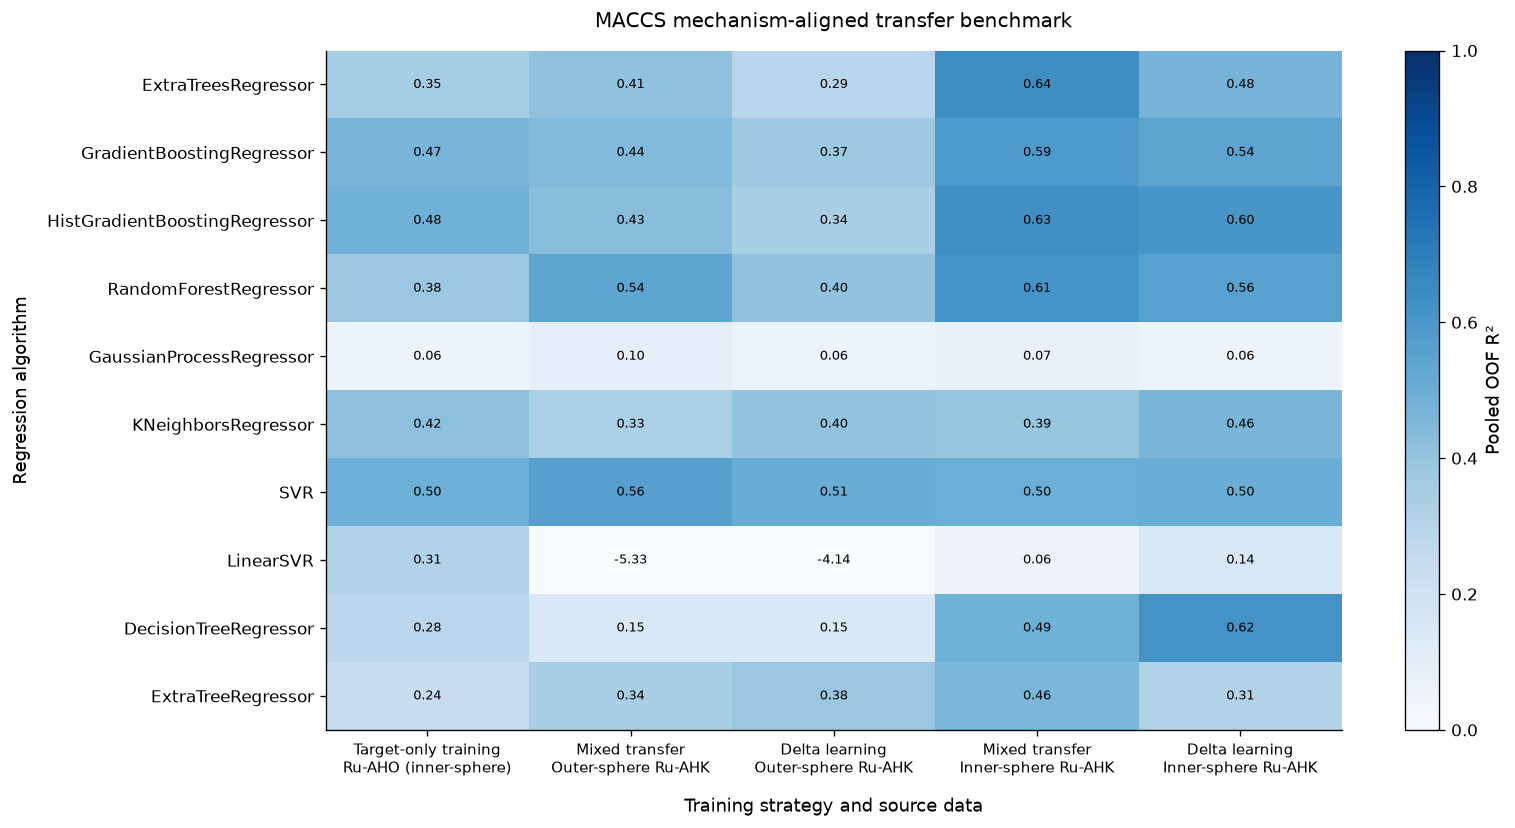

In [6]:
def pooled_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    finite = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[finite]
    y_pred = y_pred[finite]
    return {
        "R2": float(r2_score(y_true, y_pred)) if len(y_true) >= 2 else np.nan,
        "MAE": float(mean_absolute_error(y_true, y_pred)) if len(y_true) else np.nan,
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))) if len(y_true) else np.nan,
        "n_test_total": int(len(y_true)),
    }


GROUP_COLUMNS = [
    "model",
    "task_id",
    "scene_label",
    "source_domain",
    "target_domain",
    "relation_label",
    "method_label",
]

metric_rows = []
for keys, group in MULTI_MODEL_OOF_DF.groupby(GROUP_COLUMNS, dropna=False):
    row = dict(zip(GROUP_COLUMNS, keys))
    row.update(pooled_metrics(group["y_true"].to_numpy(), group["y_pred"].to_numpy()))
    metric_rows.append(row)

MULTI_MODEL_SCORE_LONG = pd.DataFrame(metric_rows)
MULTI_MODEL_SCORE_LONG.to_csv(TABLE_DIR / "maccs_pooled_oof_metrics_long.csv", index=False)
display(MULTI_MODEL_SCORE_LONG.sort_values("R2", ascending=False))


def plot_column_label(row):
    if row["method_label"] == "Target-only":
        return "Target-only\nRu-AHO inner"
    method_short = {"Mixed transfer": "Mixed", "Delta learning": "Delta"}.get(row["method_label"], row["method_label"])
    source_short = "AHK inner" if row["source_domain"] == "inner" else "AHK outer"
    return f"{source_short} -> AHO inner\n{method_short}"


plot_score = MULTI_MODEL_SCORE_LONG.copy()
plot_score["plot_col"] = plot_score.apply(plot_column_label, axis=1)
HEATMAP_COLUMN_ORDER = [
    "Target-only\nRu-AHO inner",
    "AHK outer -> AHO inner\nMixed",
    "AHK outer -> AHO inner\nDelta",
    "AHK inner -> AHO inner\nMixed",
    "AHK inner -> AHO inner\nDelta",
]

R2_HEATMAP = (
    plot_score.pivot_table(index="model", columns="plot_col", values="R2", aggfunc="mean")
    .reindex(index=MODEL_KEYS_TO_RUN)
    .reindex(columns=[col for col in HEATMAP_COLUMN_ORDER if col in plot_score["plot_col"].unique()])
)
R2_HEATMAP.to_csv(TABLE_DIR / "maccs_pooled_oof_r2_heatmap_table.csv")


def plot_annotated_heatmap(table, out_path, title, cbar_label="Pooled OOF R²", show_text=None):
    # SI output keeps labels even when the main-text figures omit text.
    if show_text is None:
        show_text = globals().get("SI_HEATMAP_SHOW_TEXT", True)
    values = table.to_numpy(dtype=float)
    color_values = np.clip(values, 0.0, 1.0)
    masked_values = np.ma.masked_invalid(color_values)

    fig_w = max(12.0, 1.8 * table.shape[1] + 4.5)
    fig_h = max(6.5, 0.48 * table.shape[0] + 2.2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(masked_values, aspect="auto", cmap="Blues", vmin=0.0, vmax=1.0)

    ax.set_xticks(np.arange(table.shape[1]))
    column_labels = {
        "Target-only\nRu-AHO inner": "Target-only training\nRu-AHO (inner-sphere)",
        "AHK outer -> AHO inner\nMixed": "Mixed transfer\nOuter-sphere Ru-AHK",
        "AHK outer -> AHO inner\nDelta": "Delta learning\nOuter-sphere Ru-AHK",
        "AHK inner -> AHO inner\nMixed": "Mixed transfer\nInner-sphere Ru-AHK",
        "AHK inner -> AHO inner\nDelta": "Delta learning\nInner-sphere Ru-AHK",
    }
    labels = [column_labels.get(col, str(col)) for col in table.columns]
    ax.set_xticklabels(labels if show_text else ["" for _ in labels], rotation=0, ha="center", fontsize=9)
    ax.set_xlabel("Training strategy and source data" if show_text else "", labelpad=12)
    ax.set_ylabel("Regression algorithm" if show_text else "", labelpad=10)
    ax.set_yticks(np.arange(table.shape[0]))
    ax.set_yticklabels(table.index if show_text else ["" for _ in table.index], fontsize=10)
    ax.set_title(title if show_text else "", pad=14)

    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            value = table.iloc[i, j]
            if pd.notna(value):
                ax.text(j, i, f"{float(value):.2f}", ha="center", va="center", fontsize=8, color="black")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label if show_text else "")
    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()


plot_annotated_heatmap(
    R2_HEATMAP,
    FIG_DIR / "maccs_selected_models_pooled_oof_R2_heatmap_0_1.svg",
    "MACCS mechanism-aligned transfer benchmark",
    "Pooled OOF R²",
)


,descriptor,model,task_id,scene_label,source_domain,target_domain,relation_label,method_label,R2,MAE,RMSE,n_test_total,display_name,selection,point_color
0,MACCS,SVR,target_only_ru_aho_inner,Ru-AHO inner target-only,none,inner,Target-only,Target-only,0.495043,0.452117,0.672032,98,Best target-only baseline,baseline,#B0B0B0
1,MACCS,SVR,ru_ahk_outer_to_ru_aho_inner,Ru-AHK outer -> Ru-AHO inner,outer,inner,Different mechanism,Mixed transfer,0.562458,0.417367,0.625565,98,Best different-mechanism transfer,different_mechanism_transfer,#B56F61
2,MACCS,ExtraTreesRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Mixed transfer,0.640186,0.350487,0.567286,98,Best same-mechanism transfer,same_mechanism_transfer,#278579


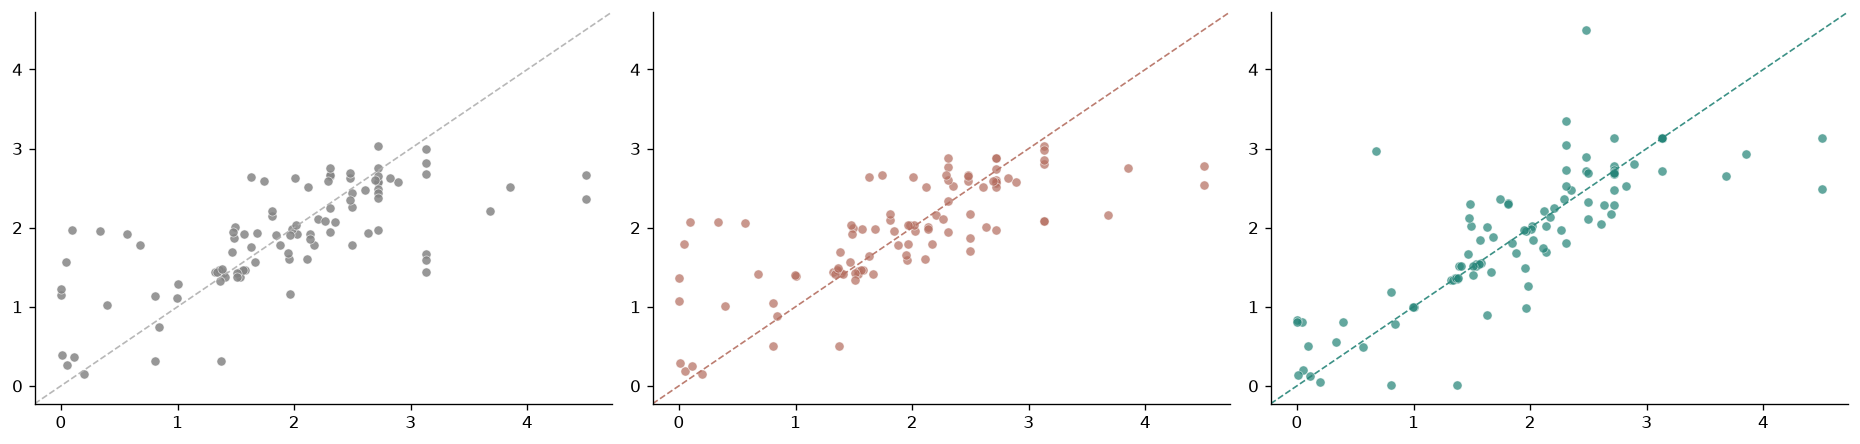

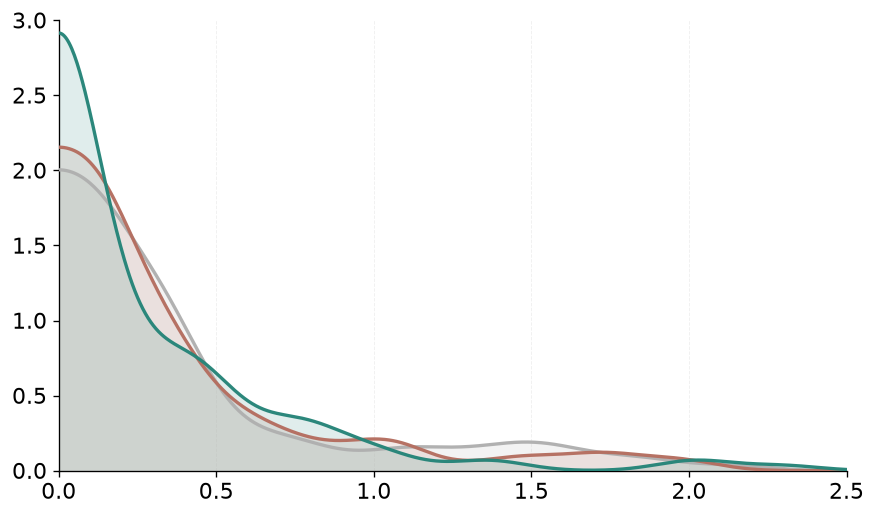

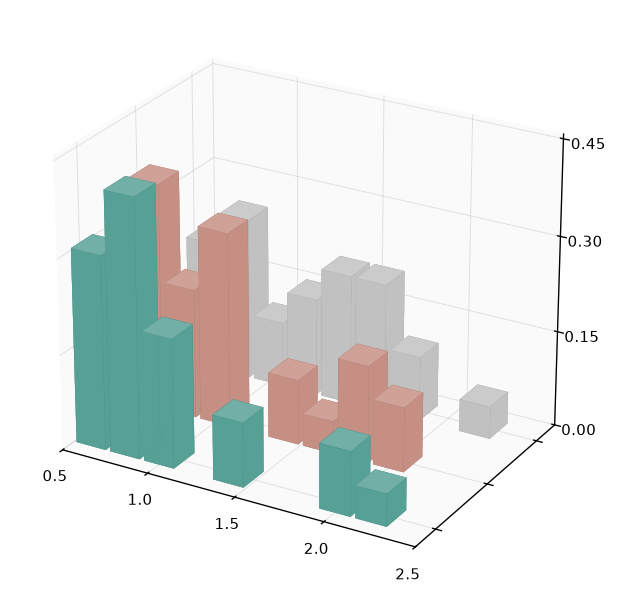

In [7]:
def select_best_score_row(score_long, selection):
    if selection == "baseline":
        sub = score_long.loc[score_long["method_label"].eq("Target-only")].copy()
    elif selection == "same_mechanism_transfer":
        sub = score_long.loc[
            score_long["relation_label"].eq("Same mechanism")
            & score_long["method_label"].isin(["Mixed transfer", "Delta learning"])
        ].copy()
    elif selection == "different_mechanism_transfer":
        sub = score_long.loc[
            score_long["relation_label"].eq("Different mechanism")
            & score_long["method_label"].isin(["Mixed transfer", "Delta learning"])
        ].copy()
    else:
        raise ValueError(selection)
    if len(sub) == 0:
        raise ValueError(f"No rows found for selection={selection!r}")
    return sub.sort_values("R2", ascending=False).iloc[0]


PARITY_SELECTION_STYLES = OrderedDict(
    [
        (
            "baseline",
            {
                "display_name": "Best target-only baseline",
                "point_color": SOURCE_RULE_COLORS["target_only"],
            },
        ),
        (
            "different_mechanism_transfer",
            {
                "display_name": "Best different-mechanism transfer",
                "point_color": SOURCE_RULE_COLORS["mechanism_mismatched"],
            },
        ),
        (
            "same_mechanism_transfer",
            {
                "display_name": "Best same-mechanism transfer",
                "point_color": SOURCE_RULE_COLORS["mechanism_aligned"],
            },
        ),
    ]
)


SELECTED_ROWS = []
for selection, style in PARITY_SELECTION_STYLES.items():
    row = select_best_score_row(MULTI_MODEL_SCORE_LONG, selection)
    item = row.to_dict()
    item["display_name"] = style["display_name"]
    item["selection"] = selection
    item["point_color"] = style["point_color"]
    SELECTED_ROWS.append(item)

SELECTED_OUTCOME_DF = pd.DataFrame(SELECTED_ROWS)
SELECTED_OUTCOME_DF.insert(0, "descriptor", "MACCS")
SELECTED_OUTCOME_DF.to_csv(TABLE_DIR / "maccs_selected_best_outcomes_for_parity.csv", index=False)
display(SELECTED_OUTCOME_DF)


def get_oof_predictions_for_selected(row):
    mask = (
        MULTI_MODEL_OOF_DF["model"].eq(row["model"])
        & MULTI_MODEL_OOF_DF["task_id"].eq(row["task_id"])
        & MULTI_MODEL_OOF_DF["method_label"].eq(row["method_label"])
    )
    pred = MULTI_MODEL_OOF_DF.loc[mask].copy()
    if len(pred) == 0:
        raise ValueError(f"Cannot find OOF predictions for selected outcome: {row.to_dict()}")
    return pred


def metrics_from_prediction_df(pred):
    return pooled_metrics(pred["y_true"].to_numpy(), pred["y_pred"].to_numpy())


def plot_parity_panel(ax, pred, title, subtitle, point_color):
    y_true = pred["y_true"].to_numpy(dtype=float)
    y_pred = pred["y_pred"].to_numpy(dtype=float)
    metric = metrics_from_prediction_df(pred)

    is_baseline = str(point_color).lower() == str(PARITY_SELECTION_STYLES["baseline"]["point_color"]).lower()
    ax.scatter(
        y_true,
        y_pred,
        s=30,
        alpha=PARITY_BASELINE_ALPHA if is_baseline else 0.72,
        color=PARITY_BASELINE_COLOR if is_baseline else point_color,
        edgecolors="white",
        linewidths=0.35,
    )

    finite = np.isfinite(y_true) & np.isfinite(y_pred)
    if finite.any():
        lo = float(np.nanmin([y_true[finite].min(), y_pred[finite].min()]))
        hi = float(np.nanmax([y_true[finite].max(), y_pred[finite].max()]))
        pad = 0.05 * (hi - lo) if hi > lo else 0.5
        lo -= pad
        hi += pad

        ax.plot(
            [lo, hi],
            [lo, hi],
            linestyle="--",
            linewidth=1.0,
            color=point_color,
            alpha=0.9,
        )
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if not SHOW_TEXT:
        # Publication-assembly mode: preserve only the data and axes/ticks.
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title("")
    else:
        # Full standalone mode: show all explanatory text together.
        ax.set_xlabel("Experimental ddG")
        ax.set_ylabel("Predicted ddG")
        ax.set_title(title)

        ax.text(
            0.04,
            0.96,
            subtitle
            + f"\nR2 = {metric['R2']:.2f}"
            + f"\nMAE = {metric['MAE']:.2f}"
            + f"\nRMSE = {metric['RMSE']:.2f}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=9,
            bbox={
                "boxstyle": "round,pad=0.3",
                "facecolor": "white",
                "alpha": 0.82,
                "edgecolor": point_color,
            },
        )


# Requested figure: three selected parity scatter plots.
fig, axes = plt.subplots(
    1,
    len(SELECTED_OUTCOME_DF),
    figsize=(5.2 * len(SELECTED_OUTCOME_DF), 3.8),
)

if len(SELECTED_OUTCOME_DF) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, SELECTED_OUTCOME_DF.iterrows()):
    pred = get_oof_predictions_for_selected(row)
    subtitle = f"{row['model']} | {row['method_label']}"

    plot_parity_panel(
        ax,
        pred,
        row["display_name"],
        subtitle,
        row["point_color"],
    )

fig.tight_layout()
fig.savefig(
    FIG_DIR / "maccs_selected_best_parity_plots.svg",
    bbox_inches="tight",
)
plt.show()


# --- Absolute-error data and KDE preparation ---
# This block is required by the overlaid absolute-error distribution below.
# It intentionally computes only the quantities needed for that requested
# figure; no ridgeline figure is generated.

def build_selected_absolute_error_table(selected_outcome_df):
    frames = []

    for _, row in selected_outcome_df.iterrows():
        pred = get_oof_predictions_for_selected(row).copy()
        pred = pred[["target_index", "fold_id", "y_true", "y_pred"]].copy()
        pred["selection"] = row["selection"]
        pred["display_name"] = row["display_name"]
        pred["model"] = row["model"]
        pred["method_label"] = row["method_label"]
        pred["point_color"] = row["point_color"]
        pred["absolute_error"] = np.abs(pred["y_pred"] - pred["y_true"])
        frames.append(pred)

    out = pd.concat(frames, ignore_index=True)

    expected_n = out.loc[out["selection"].eq("baseline")].shape[0]
    for selection in PARITY_SELECTION_STYLES:
        n = out.loc[out["selection"].eq(selection)].shape[0]
        if n != expected_n:
            raise ValueError(
                f"Selected OOF prediction count mismatch for {selection}: "
                f"expected {expected_n}, got {n}"
            )

    return out


ABS_ERROR_DF = build_selected_absolute_error_table(SELECTED_OUTCOME_DF)
ABS_ERROR_DF.to_csv(
    TABLE_DIR / "maccs_selected_absolute_prediction_errors.csv",
    index=False,
)


def reflected_gaussian_kde(values, x_grid, bandwidth):
    """Gaussian KDE with reflection at x=0 for nonnegative absolute errors."""
    values = np.asarray(values, dtype=float)
    x_grid = np.asarray(x_grid, dtype=float)

    if len(values) == 0:
        raise ValueError("No values supplied to KDE.")
    if bandwidth <= 0:
        raise ValueError("KDE bandwidth must be > 0.")

    z_pos = (x_grid[:, None] - values[None, :]) / bandwidth
    z_ref = (x_grid[:, None] + values[None, :]) / bandwidth

    norm = bandwidth * np.sqrt(2.0 * np.pi) * len(values)
    return (
        np.exp(-0.5 * z_pos**2).sum(axis=1)
        + np.exp(-0.5 * z_ref**2).sum(axis=1)
    ) / norm


ERROR_DENSITY_X = np.linspace(0.0, 2.5, 600)

# Kept under the existing variable name because the overlay function uses it.
# These are simply the three absolute-error KDEs; no ridgeline is plotted.
RIDGELINE_DENSITIES = {}
for _, row in SELECTED_OUTCOME_DF.iterrows():
    errors = ABS_ERROR_DF.loc[
        ABS_ERROR_DF["selection"].eq(row["selection"]),
        "absolute_error",
    ].to_numpy(dtype=float)

    RIDGELINE_DENSITIES[row["selection"]] = reflected_gaussian_kde(
        errors,
        ERROR_DENSITY_X,
        RIDGELINE_KDE_BANDWIDTH,
    )


# --- Overlaid KDE view of the same three absolute-error distributions ---
# Same x-grid, same reflected KDE bandwidth, same density scale.
# No MAE markers are shown here: the purpose is purely visual comparison
# of how strongly each error distribution concentrates near zero and how
# heavy its high-error tail remains.

def plot_overlaid_error_density(ax):
    ordered_rows = []
    for selection in [
        "baseline",
        "different_mechanism_transfer",
        "same_mechanism_transfer",
    ]:
        row = SELECTED_OUTCOME_DF.loc[
            SELECTED_OUTCOME_DF["selection"].eq(selection)
        ].iloc[0]
        ordered_rows.append(row)

    for row in ordered_rows:
        selection = row["selection"]
        color = row["point_color"]
        density = RIDGELINE_DENSITIES[selection]

        ax.fill_between(
            ERROR_DENSITY_X,
            0.0,
            density,
            color=color,
            alpha=OVERLAY_DENSITY_FILL_ALPHA,
            linewidth=0,
            zorder=1,
        )
        ax.plot(
            ERROR_DENSITY_X,
            density,
            color=color,
            linewidth=OVERLAY_DENSITY_LINEWIDTH,
            alpha=0.98,
            label=row["display_name"],
            zorder=3,
        )

    ax.set_xlim(0.0, 2.5)
    ax.set_ylim(0.0, 3.0)
    ax.tick_params(axis="both", which="major", labelsize=13)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xlabel("Absolute prediction error (kcal/mol)" if SHOW_TEXT else "")
    ax.set_ylabel("Probability density" if SHOW_TEXT else "")
    ax.set_title("MACCS: overlaid absolute-error distributions" if SHOW_TEXT else "")
    if SHOW_LEGEND:
        ax.legend(frameon=False, loc="upper right", fontsize=9)
    else:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    ax.grid(
        axis="x",
        linestyle="--",
        linewidth=0.55,
        alpha=0.18,
    )

# Optional SI distribution; not embedded in the entry plot.
if EXPORT_ERROR_DENSITY:
    # Standalone requested figure: overlaid absolute-error distribution.
    fig, ax = plt.subplots(figsize=(7.4, 4.4))
    plot_overlaid_error_density(ax)
    fig.tight_layout()
    fig.savefig(
        FIG_DIR / "maccs_selected_error_density_overlay.svg",
        bbox_inches="tight",
    )
    plt.show()
    

# --- High-error region: histogram density normalized by ALL reactions ---
def build_high_error_density_table(errors):
    edges = np.linspace(ERROR_TAIL_MIN, ERROR_TAIL_MAX, ERROR_TAIL_N_BINS + 1)
    rows = []
    for selection in ["baseline", "different_mechanism_transfer", "same_mechanism_transfer"]:
        values = errors.loc[errors.selection.eq(selection), "absolute_error"].to_numpy(dtype=float)
        if not len(values) or not np.isfinite(values).all() or (values < 0).any():
            raise ValueError(f"Invalid absolute errors: {selection}")
        counts, _ = np.histogram(values, bins=edges)
        # Full-sample normalization retains the probability mass of the tail.
        # Do not use density=True after filtering to the high-error subset.
        densities = counts / (len(values) * np.diff(edges))
        for left, right, count, density in zip(edges[:-1], edges[1:], counts, densities):
            rows.append(dict(selection=selection, bin_left=left, bin_right=right,
                             count=int(count), n_total=len(values), probability_density=density,
                             n_below_range=int((values < edges[0]).sum()),
                             n_above_range=int((values > edges[-1]).sum())))
    return pd.DataFrame(rows)


def plot_high_error_density_3d(ax, table):
    from matplotlib.colors import to_rgb
    from matplotlib.patches import Patch
    from matplotlib.ticker import MaxNLocator
    order = ["baseline", "different_mechanism_transfer", "same_mechanism_transfer"]
    labels = ["Target-only baseline", "Mechanism-mismatched transfer", "Mechanism-aligned transfer"]
    handles = []
    for layer, selection in enumerate(order):
        g = table.loc[table.selection.eq(selection)]
        color = np.asarray(to_rgb(PARITY_SELECTION_STYLES[selection]["point_color"]))
        face = color + (1-color)*ERROR_3D_COLOR_LIGHTEN
        dark = face*(1-ERROR_3D_SHADE_STRENGTH)
        light = face+(1-face)*.16
        faces = np.array([dark, light, face, dark, dark, face])
        g = g.loc[g["count"].gt(0)]
        if len(g):
            widths = (g.bin_right-g.bin_left).to_numpy()*0.86
            starts = g.bin_left.to_numpy()+(g.bin_right-g.bin_left).to_numpy()*0.07
            ax.bar3d(starts, np.full(len(g),(2-layer)*ERROR_3D_LAYER_GAP-ERROR_3D_BAR_DEPTH/2),
                     np.zeros(len(g)), widths, ERROR_3D_BAR_DEPTH,
                     g.probability_density.to_numpy(), color=np.tile(faces,(len(g),1)),
                     shade=False, edgecolor=tuple(face*.92),linewidth=.12,zsort="average")
        handles.append(Patch(facecolor=face,label=labels[layer]))
    ax.set_xlim(ERROR_TAIL_MIN, ERROR_TAIL_MAX)
    ax.set_xticks(np.arange(ERROR_TAIL_MIN,ERROR_TAIL_MAX+0.01,.5))
    ax.set_ylim(-.4,2*ERROR_3D_LAYER_GAP+.4)
    peak = float(table.probability_density.max())
    top = max(.1, peak*1.12) if ERROR_3D_DENSITY_MAX is None else float(ERROR_3D_DENSITY_MAX)
    if not np.isfinite(top) or top <= 0 or top < peak:
        raise ValueError("ERROR_3D_DENSITY_MAX would clip bars")
    ax.set_zlim(0,top)
    ax.zaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.set_yticks(np.arange(3)*ERROR_3D_LAYER_GAP)
    ax.set_yticklabels(labels[::-1] if SHOW_TEXT else ["", "", ""])
    ax.set_xlabel("Absolute prediction error (kcal/mol)" if SHOW_TEXT else "",labelpad=9)
    ax.set_zlabel("Probability density" if SHOW_TEXT else "",labelpad=10)
    ax.set_title("High-error region (absolute error ≥ 0.5 kcal/mol)" if SHOW_TEXT else "")
    ax.view_init(elev=ERROR_3D_ELEV,azim=ERROR_3D_AZIM)
    ax.set_proj_type("persp",focal_length=1.2)
    ax.set_box_aspect((1.7,1.25,1.35))
    for axis in (ax.xaxis,ax.yaxis,ax.zaxis):
        axis.set_pane_color((.98,.98,.98,1))
        axis._axinfo["grid"].update(color=(.65,.65,.65,.32),linewidth=.55)
    ax.tick_params(labelsize=9,pad=1)
    if SHOW_LEGEND:
        ax.legend(handles=handles,frameon=False,loc="upper left",fontsize=9)

TAIL_DENSITY_DF = build_high_error_density_table(ABS_ERROR_DF)
TAIL_DENSITY_DF.to_csv(TABLE_DIR / "maccs_selected_high_error_density.csv", index=False)
fig = plt.figure(figsize=ERROR_3D_FIGSIZE)
ax = fig.add_subplot(111, projection="3d")
plot_high_error_density_3d(ax,TAIL_DENSITY_DF)
fig.subplots_adjust(left=.02,right=.91,bottom=.06,top=.94)
fig.savefig(FIG_DIR / "maccs_selected_high_error_density_3d.svg",bbox_inches="tight",facecolor="white")
plt.show()
plt.close(fig)


## 5.1 All Ru-AHK as source data (text-only comparison)

将当前两个 Ru-AHK 源域直接合并（inner + outer，当前应为 495 + 1539 = 2034 条），对原 Ru-AHO 目标域进行迁移评价。保留相同的目标五折划分、模型池、参数、预处理以及 **Mixed transfer / Delta learning** 方法。合并后的源域不做下采样，不新增源域自身的交叉验证。

本模块放在正文绘图之后、种子扫描之前，只打印每个模型/迁移方法的 **pooled target OOF R² 和 MAE（kcal/mol）**，最后再次打印本描述符中最高 R² 对应的 **descriptor、model、transfer_method、R2、MAE**。按未四舍五入的 R² 选优；完全并列时优先更低 MAE。失败项明确报告，不作为有效候选。

结果仅保存在内存变量 `ALL_AHK_METRICS`、`ALL_AHK_OOF` 和 `ALL_AHK_BEST`，不新增图，也不改写原迁移结果。原 OOF 缓存导致特征被跳过加载时，本模块自动补载；重复执行本模块会重新训练此次比较。无需运行后面的种子扫描。


In [8]:
# All Ru-AHK source comparison: text output only; original results remain unchanged.
def run_all_ahk_source_comparison():
    required_domains = ('ru_ahk_inner', 'ru_ahk_outer', 'ru_aho_inner')
    # Earlier target-result caches can skip all feature loading; load lazily here.
    if not all(key in FEATURES for key in required_domains):
        cached = load_cached_feature_matrices()
        if cached is None:
            molecule_cache = {}
            cached = OrderedDict((key, build_feature_matrix(df, cache=molecule_cache))
                                 for key, df in DOMAINS.items())
            save_cached_feature_matrices(cached)
        FEATURES.update(cached)

    x_source = np.vstack([FEATURES['ru_ahk_inner'], FEATURES['ru_ahk_outer']])
    y_source = np.concatenate([TARGETS['ru_ahk_inner'], TARGETS['ru_ahk_outer']])
    x_target = FEATURES['ru_aho_inner']
    y_target = np.asarray(TARGETS['ru_aho_inner'], dtype=float)
    if len(x_source) != len(y_source) or len(x_target) != len(y_target):
        raise ValueError('Feature/label row counts do not match')
    if not np.isfinite(y_source).all() or not np.isfinite(y_target).all():
        raise ValueError('Labels must be finite')
    task = {
        'task_id': 'all_ru_ahk_to_ru_aho_inner',
        'source_key': 'all_ru_ahk', 'target_key': 'ru_aho_inner',
        'source_domain': 'inner+outer', 'target_domain': 'inner',
        'relation_label': 'All Ru-AHK',
        'scene_label': 'All Ru-AHK (inner + outer) -> Ru-AHO inner',
    }
    expected_folds = np.zeros(len(y_target), dtype=int)
    for fold_id, (_, test_idx) in enumerate(kfold_splitter(y_target).split(x_target, y_target), 1):
        expected_folds[test_idx] = fold_id
    print(f'\nMACCS | All Ru-AHK source: '
          f'{len(TARGETS["ru_ahk_inner"])} inner + {len(TARGETS["ru_ahk_outer"])} outer '
          f'= {len(y_source)} reactions; target: {len(y_target)} reactions')
    print('Metrics: pooled target OOF R2 and MAE (kcal/mol); original target folds and model parameters.')
    metric_rows, oof_frames = [], []
    for model_key in MODEL_KEYS_TO_RUN:
        try:
            # Reuse the exact original Mixed transfer and Delta learning implementation.
            rows = run_transfer_oof(model_key, task, x_source, y_source, x_target, y_target)
            frame = pd.DataFrame(rows)
            current_metrics = []
            for method in ['Mixed transfer', 'Delta learning']:
                group = frame.loc[frame['method_label'].eq(method)].sort_values('target_index')
                if (len(group) != len(y_target)
                    or not np.array_equal(group['target_index'].to_numpy(), np.arange(len(y_target)))
                    or not np.array_equal(group['fold_id'].to_numpy(), expected_folds)
                    or not np.allclose(group['y_true'].to_numpy(), y_target, rtol=0, atol=0)
                    or not np.isfinite(group['y_pred'].to_numpy()).all()):
                    raise RuntimeError(f'Incomplete or misaligned OOF predictions: {model_key}/{method}')
                current_metrics.append({
                    'descriptor': 'MACCS', 'model': model_key, 'transfer_method': method,
                    'R2': float(r2_score(group['y_true'], group['y_pred'])),
                    'MAE': float(mean_absolute_error(group['y_true'], group['y_pred'])),
                    'status': 'ok', 'error': '',
                })
            metric_rows.extend(current_metrics)
            oof_frames.append(frame)
            for row in current_metrics:
                print(f'{row["descriptor"]} | {row["model"]} | {row["transfer_method"]} | '
                      f'R2 = {row["R2"]:.6f} | MAE = {row["MAE"]:.6f}')
        except Exception as exc:
            print(f'FAILED: {model_key}: {exc!r}')
            for method in ['Mixed transfer', 'Delta learning']:
                metric_rows.append(dict(descriptor='MACCS', model=model_key,
                                        transfer_method=method, R2=np.nan, MAE=np.nan,
                                        status='failed', error=repr(exc)))
    metrics = pd.DataFrame(metric_rows, columns=[
        'descriptor', 'model', 'transfer_method', 'R2', 'MAE', 'status', 'error'])
    predictions = pd.concat(oof_frames, ignore_index=True) if oof_frames else pd.DataFrame()
    valid = metrics.loc[metrics['status'].eq('ok') & np.isfinite(metrics['R2'])].copy()
    # Selection is by unrounded pooled R2; exact ties use lower MAE, then names.
    valid = valid.sort_values(['R2', 'MAE', 'model', 'transfer_method'],
                              ascending=[False, True, True, True], kind='mergesort')
    if valid.empty:
        print('\nNo valid all-Ru-AHK result; no best model selected.')
        best = valid.copy()
    else:
        best = valid.head(1)[['descriptor', 'model', 'transfer_method', 'R2', 'MAE']].copy()
        qualifier = ' (among successful evaluations; failures listed above)' if metrics.status.eq('failed').any() else ''
        print('\nHighest pooled OOF R2 — all Ru-AHK source (MACCS)'+qualifier)
        print(best.to_string(index=False, float_format=lambda value: f'{value:.6f}'))
    return metrics, predictions, best


ALL_AHK_METRICS, ALL_AHK_OOF, ALL_AHK_BEST = run_all_ahk_source_comparison()


Loaded cached combined MACCS feature matrix: (2132, 838)

MACCS | All Ru-AHK source: 495 inner + 1539 outer = 2034 reactions; target: 98 reactions
Metrics: pooled target OOF R2 and MAE (kcal/mol); original target folds and model parameters.
MACCS | ExtraTreesRegressor | Mixed transfer | R2 = 0.524232 | MAE = 0.425860
MACCS | ExtraTreesRegressor | Delta learning | R2 = 0.502648 | MAE = 0.410143
MACCS | GradientBoostingRegressor | Mixed transfer | R2 = 0.419767 | MAE = 0.511249
MACCS | GradientBoostingRegressor | Delta learning | R2 = 0.346237 | MAE = 0.470458
MACCS | HistGradientBoostingRegressor | Mixed transfer | R2 = 0.525821 | MAE = 0.444364
MACCS | HistGradientBoostingRegressor | Delta learning | R2 = 0.377883 | MAE = 0.506973
MACCS | RandomForestRegressor | Mixed transfer | R2 = 0.607715 | MAE = 0.429457
MACCS | RandomForestRegressor | Delta learning | R2 = 0.458523 | MAE = 0.469487
MACCS | GaussianProcessRegressor | Mixed transfer | R2 = 0.092993 | MAE = 0.685581
MACCS | Gaussian

## 6. Seed-landscape diagnostic across target split seeds

To avoid making the validation depend on a hand-picked meta-seed protocol, this section exhaustively scans target-domain 5-fold split seeds from 0 to 100. The model and transfer method selected above are kept fixed, and the diagnostic reports how much the same-mechanism transfer setting outperforms the different-mechanism transfer setting under each split.



Feature matrices available for seed-landscape diagnostic: {'ru_ahk_inner': (495, 838), 'ru_ahk_outer': (1539, 838), 'ru_aho_inner': (98, 838)}
Same-mechanism setting: same_mechanism_transfer|ExtraTreesRegressor|ru_ahk_inner_to_ru_aho_inner|Mixed transfer
Different-mechanism setting: different_mechanism_transfer|SVR|ru_ahk_outer_to_ru_aho_inner|Mixed transfer
Loaded cached seed-landscape metrics from /home/syz/ru-mechanism-transfer/results/1_1_maccs_mechanism_transfer/tables/maccs_seed_landscape_metrics.csv


,split_seed,same_model,same_method_label,different_model,different_method_label,same_mechanism_R2,different_mechanism_R2,delta_R2_same_minus_different
42,42,ExtraTreesRegressor,Mixed transfer,SVR,Mixed transfer,0.640186,0.562458,0.077728


Saved necessary Section 6 metrics table to: /home/syz/ru-mechanism-transfer/results/1_1_maccs_mechanism_transfer/tables/maccs_seed_landscape_metrics.csv


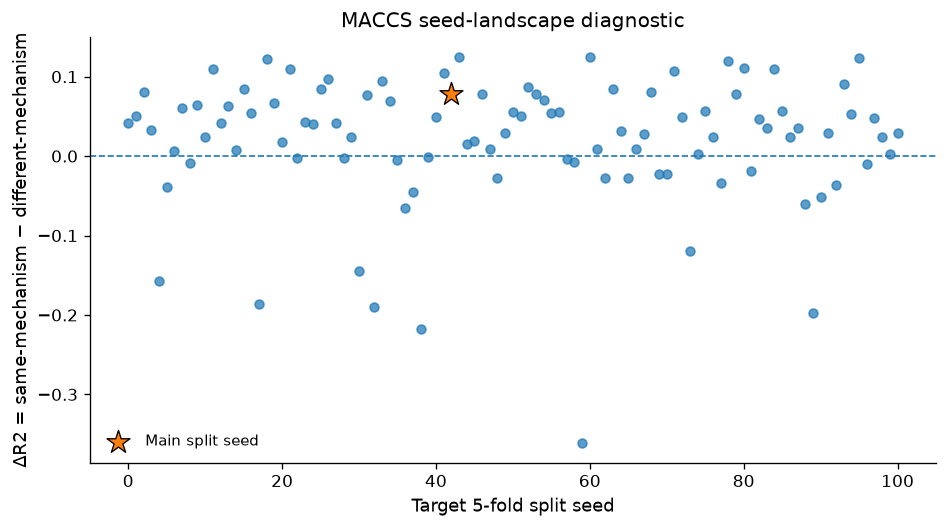

Saved Section 6 diagnostic figure to: /home/syz/ru-mechanism-transfer/results/1_1_maccs_mechanism_transfer/figures/maccs_seed_landscape_diagnostic.svg


In [9]:
SEED_LANDSCAPE_MIN_SEED = 0
SEED_LANDSCAPE_MAX_SEED = 100
SEED_LANDSCAPE_SPLIT_SEEDS = list(range(SEED_LANDSCAPE_MIN_SEED, SEED_LANDSCAPE_MAX_SEED + 1))
FORCE_RECOMPUTE_SEED_LANDSCAPE = False

SEED_LANDSCAPE_METRICS_TABLE = TABLE_DIR / "maccs_seed_landscape_metrics.csv"
SEED_LANDSCAPE_FIG = FIG_DIR / "maccs_seed_landscape_diagnostic.svg"

# Remove verbose outputs from the earlier meta-seed validation version.
OBSOLETE_SECTION6_OUTPUTS = [
    TABLE_DIR / "maccs_meta_seed_generated_split_seeds.csv",
    TABLE_DIR / "maccs_meta_seed_split_validation_metrics.csv",
    TABLE_DIR / "maccs_meta_seed_split_validation_predictions.csv",
    FIG_DIR / "maccs_meta_seed_split_validation_boxplot.svg",
]
for obsolete_path in OBSOLETE_SECTION6_OUTPUTS:
    if obsolete_path.exists():
        obsolete_path.unlink()


# Make feature matrices available for the seed-landscape section.
# If the main OOF table was loaded from cache, earlier cells may have skipped feature loading.
def ensure_maccs_features_available():
    global FEATURES, FEATURE_CACHE, TARGETS

    required_keys = list(DOMAINS.keys())
    existing_features = globals().get("FEATURES", OrderedDict())
    if isinstance(existing_features, OrderedDict) and all(key in existing_features for key in required_keys):
        FEATURES = existing_features
        TARGETS = OrderedDict((key, df[TARGET_COLUMN].to_numpy(dtype=float)) for key, df in DOMAINS.items())
        return

    cached_features = load_cached_feature_matrices()
    if cached_features is not None:
        FEATURES = cached_features
    else:
        print("MACCS feature cache is missing or incompatible; rebuilding features for seed-landscape diagnostic.")
        FEATURE_CACHE = {}
        FEATURES = OrderedDict()
        for key, df in DOMAINS.items():
            print(f"Building MACCS features for {key}: {len(df)} rows")
            FEATURES[key] = build_feature_matrix(df, cache=FEATURE_CACHE)
        save_cached_feature_matrices(FEATURES)

    TARGETS = OrderedDict((key, df[TARGET_COLUMN].to_numpy(dtype=float)) for key, df in DOMAINS.items())


def get_transfer_task_by_id(task_id):
    for task in TRANSFER_TASKS:
        if task["task_id"] == task_id:
            return task
    raise ValueError(f"Unknown transfer task_id: {task_id!r}")


def kfold_splitter_for_seed(y_target, split_seed):
    n_splits = min(int(N_FOLDS), int(len(y_target)))
    if n_splits < 2:
        raise ValueError("The Ru-AHO target domain has too few samples for OOF evaluation.")
    return KFold(n_splits=n_splits, shuffle=True, random_state=int(split_seed))


def run_selected_transfer_outcome_for_seed(selected_row, split_seed):
    """Run one fixed selected transfer outcome under a target-domain split seed."""
    model_key = selected_row["model"]
    method_label = selected_row["method_label"]
    task = get_transfer_task_by_id(selected_row["task_id"])

    x_source = FEATURES[task["source_key"]]
    y_source = TARGETS[task["source_key"]]
    x_target = FEATURES["ru_aho_inner"]
    y_target = TARGETS["ru_aho_inner"]
    cv = kfold_splitter_for_seed(y_target, split_seed)

    source_prior_model = make_model(model_key)
    source_prior_model.fit(x_source, y_source)

    rows = []
    for fold_id, (train_idx, test_idx) in enumerate(cv.split(x_target, y_target), start=1):
        x_train = x_target[train_idx]
        y_train = y_target[train_idx]
        x_test = x_target[test_idx]
        y_test = y_target[test_idx]

        if method_label == "Mixed transfer":
            model = make_model(model_key)
            model.fit(np.vstack([x_source, x_train]), np.concatenate([y_source, y_train]))
            pred = predict_1d(model, x_test)
        elif method_label == "Delta learning":
            delta_model = make_model(model_key)
            source_prior_train = predict_1d(source_prior_model, x_train)
            delta_model.fit(x_train, y_train - source_prior_train)
            pred = predict_1d(source_prior_model, x_test) + predict_1d(delta_model, x_test)
        else:
            raise ValueError(f"This seed-landscape diagnostic expects a transfer method, got {method_label!r}")

        for local_idx, truth, pred_value in zip(test_idx, y_test, pred):
            rows.append(
                {
                    "split_seed": int(split_seed),
                    "selection": selected_row["selection"],
                    "model": model_key,
                    "task_id": selected_row["task_id"],
                    "relation_label": selected_row["relation_label"],
                    "method_label": method_label,
                    "fold_id": int(fold_id),
                    "target_index": int(local_idx),
                    "y_true": float(truth),
                    "y_pred": float(pred_value),
                }
            )
    return pd.DataFrame(rows)


def selected_transfer_row(selection):
    sub = SELECTED_OUTCOME_DF.loc[SELECTED_OUTCOME_DF["selection"].eq(selection)].copy()
    if len(sub) != 1:
        raise ValueError(f"Expected exactly one selected row for {selection!r}, found {len(sub)}")
    row = sub.iloc[0]
    if row["method_label"] == "Target-only":
        raise ValueError(f"Seed-landscape diagnostic requires transfer rows, got target-only for {selection!r}")
    return row


SAME_SELECTED_ROW = selected_transfer_row("same_mechanism_transfer")
DIFF_SELECTED_ROW = selected_transfer_row("different_mechanism_transfer")


def selected_signature(row):
    return "|".join(
        [
            str(row["selection"]),
            str(row["model"]),
            str(row["task_id"]),
            str(row["method_label"]),
        ]
    )


EXPECTED_SAME_SIGNATURE = selected_signature(SAME_SELECTED_ROW)
EXPECTED_DIFF_SIGNATURE = selected_signature(DIFF_SELECTED_ROW)


def seed_landscape_cache_is_compatible(path):
    if FORCE_RECOMPUTE_SEED_LANDSCAPE or not path.exists():
        return False
    try:
        cached = pd.read_csv(path)
    except (EmptyDataError, pd.errors.ParserError):
        return False

    required = {
        "split_seed",
        "same_mechanism_R2",
        "different_mechanism_R2",
        "delta_R2_same_minus_different",
        "same_signature",
        "different_signature",
    }
    if not required.issubset(cached.columns):
        return False

    observed_seeds = set(cached["split_seed"].astype(int).unique())
    expected_seeds = set(SEED_LANDSCAPE_SPLIT_SEEDS)
    if observed_seeds != expected_seeds:
        return False

    return (
        set(cached["same_signature"].astype(str).unique()) == {EXPECTED_SAME_SIGNATURE}
        and set(cached["different_signature"].astype(str).unique()) == {EXPECTED_DIFF_SIGNATURE}
    )


ensure_maccs_features_available()
print("Feature matrices available for seed-landscape diagnostic:", {key: FEATURES[key].shape for key in FEATURES})
print("Same-mechanism setting:", EXPECTED_SAME_SIGNATURE)
print("Different-mechanism setting:", EXPECTED_DIFF_SIGNATURE)

if seed_landscape_cache_is_compatible(SEED_LANDSCAPE_METRICS_TABLE):
    SEED_LANDSCAPE_METRICS = pd.read_csv(SEED_LANDSCAPE_METRICS_TABLE)
    print(f"Loaded cached seed-landscape metrics from {SEED_LANDSCAPE_METRICS_TABLE}")
else:
    metric_rows = []
    for split_seed in SEED_LANDSCAPE_SPLIT_SEEDS:
        print(f"Seed-landscape diagnostic: split_seed={split_seed}")

        same_pred = run_selected_transfer_outcome_for_seed(SAME_SELECTED_ROW, split_seed)
        diff_pred = run_selected_transfer_outcome_for_seed(DIFF_SELECTED_ROW, split_seed)
        same_metrics = pooled_metrics(same_pred["y_true"].to_numpy(), same_pred["y_pred"].to_numpy())
        diff_metrics = pooled_metrics(diff_pred["y_true"].to_numpy(), diff_pred["y_pred"].to_numpy())

        metric_rows.append(
            {
                "descriptor": "MACCS",
                "split_seed": int(split_seed),
                "same_signature": EXPECTED_SAME_SIGNATURE,
                "different_signature": EXPECTED_DIFF_SIGNATURE,
                "same_model": SAME_SELECTED_ROW["model"],
                "same_task_id": SAME_SELECTED_ROW["task_id"],
                "same_method_label": SAME_SELECTED_ROW["method_label"],
                "different_model": DIFF_SELECTED_ROW["model"],
                "different_task_id": DIFF_SELECTED_ROW["task_id"],
                "different_method_label": DIFF_SELECTED_ROW["method_label"],
                "same_mechanism_R2": same_metrics["R2"],
                "different_mechanism_R2": diff_metrics["R2"],
                "delta_R2_same_minus_different": same_metrics["R2"] - diff_metrics["R2"],
                "same_mechanism_MAE": same_metrics["MAE"],
                "different_mechanism_MAE": diff_metrics["MAE"],
                "same_mechanism_RMSE": same_metrics["RMSE"],
                "different_mechanism_RMSE": diff_metrics["RMSE"],
                "n_test_total": same_metrics["n_test_total"],
            }
        )

    SEED_LANDSCAPE_METRICS = pd.DataFrame(metric_rows).sort_values("split_seed").reset_index(drop=True)
    SEED_LANDSCAPE_METRICS.to_csv(SEED_LANDSCAPE_METRICS_TABLE, index=False)

SEED_LANDSCAPE_METRICS = SEED_LANDSCAPE_METRICS.sort_values("split_seed").reset_index(drop=True)

main_seed_rows = SEED_LANDSCAPE_METRICS.loc[
    SEED_LANDSCAPE_METRICS["split_seed"].astype(int).eq(int(RANDOM_STATE)),
    [
        "split_seed",
        "same_model",
        "same_method_label",
        "different_model",
        "different_method_label",
        "same_mechanism_R2",
        "different_mechanism_R2",
        "delta_R2_same_minus_different",
    ],
]
display(main_seed_rows)
print(f"Saved necessary Section 6 metrics table to: {SEED_LANDSCAPE_METRICS_TABLE}")

fig, ax = plt.subplots(figsize=(8.0, 4.5))
ax.scatter(
    SEED_LANDSCAPE_METRICS["split_seed"].astype(int),
    SEED_LANDSCAPE_METRICS["delta_R2_same_minus_different"].astype(float),
    s=28,
    alpha=0.72,
)
ax.axhline(0.0, linestyle="--", linewidth=1.0)

main_split_df = SEED_LANDSCAPE_METRICS.loc[
    SEED_LANDSCAPE_METRICS["split_seed"].astype(int).eq(int(RANDOM_STATE))
]
if len(main_split_df):
    ax.scatter(
        main_split_df["split_seed"].astype(int),
        main_split_df["delta_R2_same_minus_different"].astype(float),
        marker="*",
        s=210,
        edgecolor="black",
        linewidth=0.8,
        zorder=4,
        label="Main split seed",
    )
    ax.legend(frameon=False, loc="best")

ax.set_xlabel("Target 5-fold split seed")
ax.set_ylabel("ΔR2 = same-mechanism − different-mechanism")
ax.set_title("MACCS seed-landscape diagnostic")
fig.tight_layout()
fig.savefig(SEED_LANDSCAPE_FIG, bbox_inches="tight")
plt.show()
print(f"Saved Section 6 diagnostic figure to: {SEED_LANDSCAPE_FIG}")

